# Deep Active Learning with Frozen Vision Transformer

> **_Google Colab Note:_** If the notebook fails to run after installing the needed packages, try to restart the runtime (Ctrl + M) under Runtime -> Restart session.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](<colab_link>)

**Notebook Dependencies**

Uncomment the following cells to install all dependencies for this tutorial.

In [1]:
# !pip install scikit-activeml torch tqdm datasets transformers

<hr style="border-style: solid; border-top: 1px solid; border-right: 0; border-bottom: 0; border-left: 0;">

This tutorial aims to demonstrate a practical comparison study using our
```scikit-activeml``` library. The workflow involves utilizing a
self-supervised learning model, specifically ```DINOv2``` from [1], to
generate embeddings for the CIFAR-100 dataset [2]. Subsequently, various
active learning strategies will be employed to intelligently select samples
for labeling.

**Key Steps:**
1. **Self-Supervised Learning Model:** Utilize the DINOv2 model to create
embedding dataset for CIFAR-100 dataset.

2. **Active Learning Strategies:** Employ different active learning strategies provided by our library, including:
    - Random Sampling,
    - Uncertainty Sampling,
    - Discriminative Active Learning,
    - CoreSet,
    - TypiClust,
    - Badge,
    - ProbCover,
    - DropQuery,
    - Falcun.

3. **Batch Sample Selection:** Use each active learning strategy to select a batch of samples for labeling.

4. **Plotting the results:** By the end of this notebook, we'll compare the
accuracy of the aforementioned active learning strategies.

**References:**

[1] Oquab, M., Darcet, T., Moutakanni, T., Vo, H. V., Szafraniec, M.,
Khalidov, V., ... & Bojanowski, P. DINOv2: Learning Robust Visual Features
without Supervision. Transactions on Machine Learning Research.

[2] Krizhevsky, A., & Hinton, G. (2009). Learning Multiple Layers of
Features from Tiny Images.

In [2]:
# Comment in for speedup, if you have cuML installed.
# %load_ext cuml.accell<<
import numpy as np
import matplotlib as mlp
import matplotlib.pyplot as plt
import torch
import warnings

from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import SelfTrainingClassifier
from skactiveml.classifier import SklearnClassifier
from skactiveml.pool import (
    UncertaintySampling,
    RandomSampling,
    DiscriminativeAL,
    CoreSet,
    TypiClust,
    Badge,
    DropQuery,
    ProbCover,
    Falcun,
    SubSamplingWrapper,
)
from skactiveml.utils import call_func
from transformers import AutoImageProcessor, Dinov2Model
from tqdm import tqdm


warnings.filterwarnings("ignore")
mlp.rcParams["figure.facecolor"] = "white"
device = "cuda" if torch.cuda.is_available() else "cpu"

## Embed CIFAR-100 Images with DINOv2

In this step, we focus on preparing the datasets using the self-supervised
learning model DINOv2. DINOv2, short for "self-distillation with no labels",
 is a popular vision foundation model that excels at providing meaningful
 representations for image data.

In [3]:
# Download data.
ds = load_dataset("uoft-cs/cifar100")

# Download DINOv2 ViT/S-14 as embedding model.
processor = AutoImageProcessor.from_pretrained(
    "facebook/dinov2-small", use_fast=True
)
model = Dinov2Model.from_pretrained("facebook/dinov2-small").to(device).eval()


# Embed CIFAR-100 images.
def embed(batch):
    inputs = processor(images=batch["img"], return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**inputs).last_hidden_state[:, 0]
    batch["emb"] = out.cpu().numpy()
    return batch


ds = ds.map(embed, batched=True, batch_size=32)
X_pool = np.stack(ds["train"]["emb"], dtype=np.float32)
y_pool = np.array(ds["train"]["fine_label"], dtype=np.int64)
X_test = np.stack(ds["test"]["emb"], dtype=np.float32)
y_test = np.array(ds["test"]["fine_label"], dtype=np.int64)

## Random Seed Management

To ensure experiment reproducibility, it's important to set random states for all components that might use them. For simplicity, we set a single fixed random state and use helper functions to generate new seeds and random states. It's important to note that the ```master_random_state``` should only be used to create new random states or random seeds.

In [4]:
master_random_state = np.random.RandomState(0)


def gen_seed(random_state: np.random.RandomState):
    """
    Generate a seed for a random number generator.

    Parameters:
    - random_state (np.random.RandomState): Random state object.

    Returns:
    - int: Generated seed.
    """
    return random_state.randint(0, 2**31)


def gen_random_state(random_state: np.random.RandomState):
    """
    Generate a new random state object based on a given random state.

    Parameters:
    - random_state (np.random.RandomState): Random state object.

    Returns:
    - np.random.RandomState: New random state object.
    """
    return np.random.RandomState(gen_seed(random_state))

## Classification Models and Query Strategies

The embeddings we have computed can be used as an input to a classification model. For this guide, we use `LogisticRegression` from `sklearn`. Moreover, we handle the creation of query strategies using factory functions to simplify the separation of query strategies across repetitions.

In [ ]:
n_features, classes = X_pool.shape[1], np.unique(y_pool)
missing_label = -1
def create_classifier(name, classes, random_state):
    return classifier_factory_functions[name](classes, random_state)
classifier_factory_functions = {
    'LogisticRegression': lambda classes, random_state: SklearnClassifier(
        LogisticRegression(
            verbose=0,
            tol=1e-3,
            C=0.1,
            max_iter=10000,
            random_state=gen_seed(random_state)
        ),
        classes=classes,
        random_state=gen_seed(random_state),
        missing_label=missing_label
    )
}

def create_query_strategy(name, random_state):
    return query_strategy_factory_functions[name](random_state)

query_strategy_factory_functions = {
    "RandomSampling": lambda random_state: RandomSampling(
        random_state=gen_seed(random_state), missing_label=missing_label
    ),
    # "UncertaintySampling": lambda random_state: UncertaintySampling(
    #     random_state=gen_seed(random_state), missing_label=missing_label
    # ),
    # "DiscriminativeAL": lambda random_state: DiscriminativeAL(
    #     random_state=gen_seed(random_state), missing_label=missing_label
    # ),
    # "CoreSet": lambda random_state: CoreSet(
    #     random_state=gen_seed(random_state), missing_label=missing_label
    # ),
    # "TypiClust": lambda random_state: TypiClust(
    #     random_state=gen_seed(random_state), missing_label=missing_label
    # ),
    # "Badge": lambda random_state: Badge(
    #     random_state=gen_seed(random_state), missing_label=missing_label
    # ),
    # "DropQuery": lambda random_state: DropQuery(
    #     random_state=gen_seed(random_state),
    #     missing_label=missing_label,
    # ),
    # "ProbCover": lambda random_state: ProbCover(
    #     random_state=gen_seed(random_state), missing_label=missing_label
    # ),
    # "Falcun": lambda random_state: Falcun(
    #     random_state=gen_seed(random_state), missing_label=missing_label
    # ),
}

## Experiment Parameters

For this experiment, we need to define how the strategies should be compared against one another. Here the number of repetitions (```n_reps```), the number of cycles (```n_cycles```), and the size of each query (```query_batch_size```) need to be defined. 

In [48]:
n_reps = 1
n_cycles = 20
query_batch_size = 100
classifier_names = classifier_factory_functions.keys()
query_strategy_names = query_strategy_factory_functions.keys()

## Experiment Loop

The actual experiment loops over all query strategies. The accuracy for the test set is stored for each cycle and repetition in the `results` dictionary.

In [49]:
results = {}
for clf_name in classifier_names:
    for use_ssl in [False, True]:
        for qs_name in query_strategy_names:
            accuracies = np.full((n_reps, n_cycles + 1), np.nan)
            for i_rep in range(n_reps):
                y_train = np.full(shape=len(X_pool), fill_value=missing_label)

                qs = create_query_strategy(
                    qs_name,
                    random_state=gen_random_state(np.random.RandomState(i_rep)),
                )
                qs = SubSamplingWrapper(
                    query_strategy=qs,
                    missing_label=missing_label,
                    random_state=gen_random_state(np.random.RandomState(i_rep)),
                    exclude_non_subsample=True,
                    max_candidates=0.1,
                )
                raw_clf = create_classifier(
                    clf_name,
                    classes,
                    gen_random_state(master_random_state)
                )
                if use_ssl:
                    clf = SklearnClassifier(
                        SelfTrainingClassifier(
                            clf,
                            threshold=0.95,
                            max_iter=0,
                        ),
                        include_unlabeled_samples=True,
                        classes=classes,
                        random_state=gen_random_state(np.random.RandomState(i_rep)),
                        missing_label=missing_label
                    )
                else:
                    clf=raw_clf
                clf.fit(X_pool, y_train)
                accuracies[i_rep, 0] = clf.score(X_test, y_test)

                for c in tqdm(
                    range(1, n_cycles + 1), desc=f"Repeat {i_rep + 1} with {qs_name}"
                ):
                    query_idx = call_func(
                        qs.query,
                        X=X_pool,
                        y=y_train,
                        batch_size=query_batch_size,
                        clf=clf,
                        discriminator=clf,
                        update=True,
                        fit_clf=False
                    )
                    y_train[query_idx] = y_pool[query_idx]
                    if use_ssl:
                        clf.estimator.set_params(max_iter=max(0, c-15))
                    clf.fit(X_pool, y_train)
                    accuracies[i_rep, c] = clf.score(X_test, y_test)
                    print(accuracies[i_rep, c])

            results[(clf_name, use_ssl, qs_name)] = accuracies

Repeat 1 with RandomSampling:  10%|█         | 2/20 [00:00<00:02,  6.98it/s]

0.2137
0.3249


Repeat 1 with RandomSampling:  20%|██        | 4/20 [00:00<00:02,  6.88it/s]

0.4015
0.4642


Repeat 1 with RandomSampling:  30%|███       | 6/20 [00:00<00:01,  8.21it/s]

...

0.7571


Repeat 1 with RandomSampling:  95%|█████████▌| 19/20 [00:05<00:00,  1.69it/s]

0.7664


Repeat 1 with RandomSampling: 100%|██████████| 20/20 [00:05<00:00,  3.40it/s]

0.7711


## Resulting Plotting

We use learning curves to compare strategies. We visualize the average accuracy over all repetitions. In addition, the legend provides insight into the area under the learning curve, which indicates the average accuracy over all cycles.

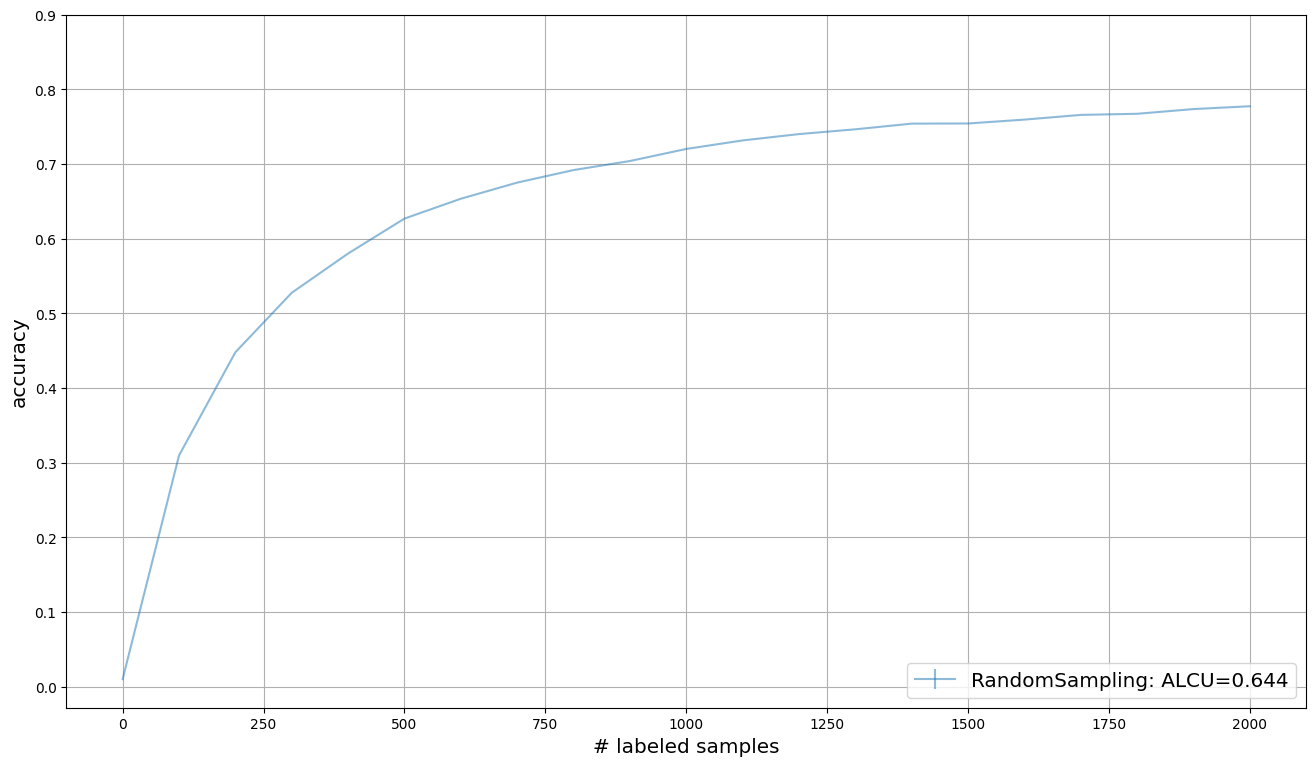

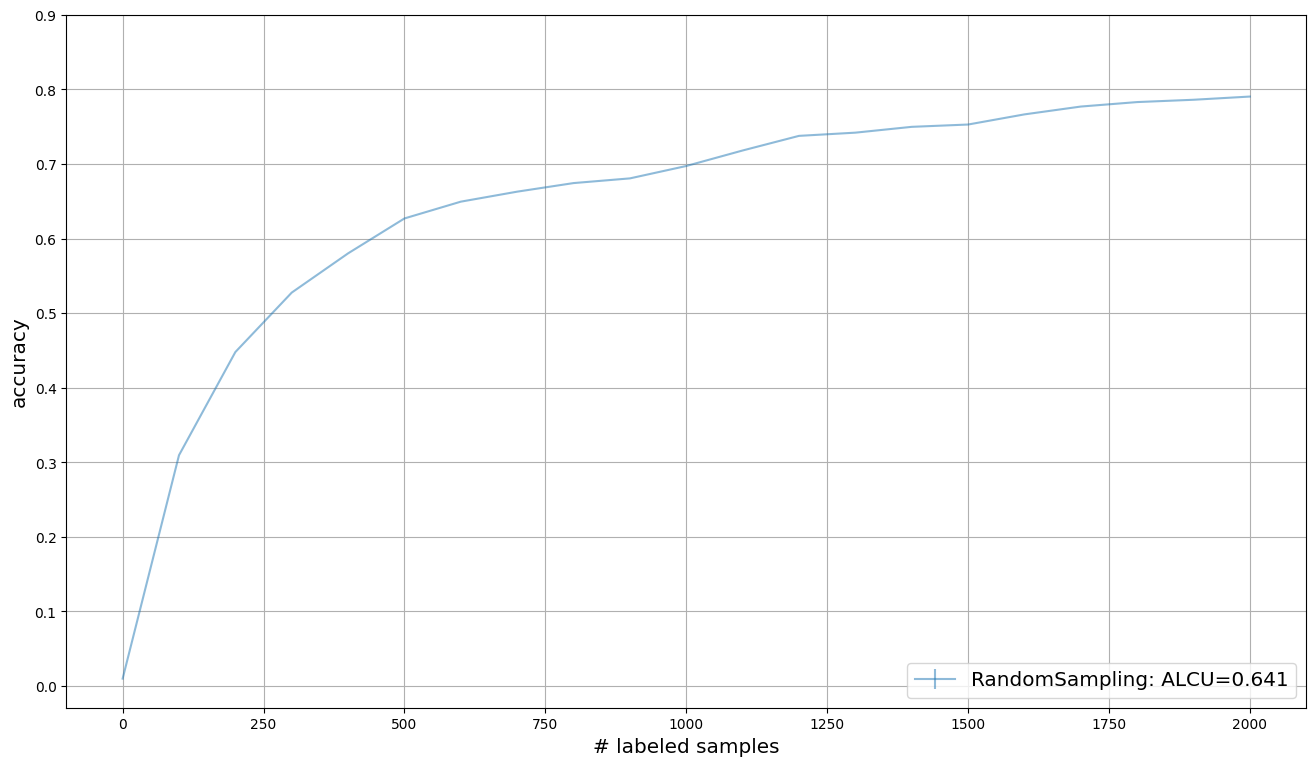

In [46]:
for clf_name in classifier_names:
    for use_ssl in [False, True]:
        plt.figure(figsize=(16, 9))
        for qs_name in query_strategy_names:
            key = (clf_name, use_ssl, qs_name)
            result = results[key]
            reshaped_result = result.reshape((-1, n_cycles + 1))
            errorbar_mean = np.mean(reshaped_result, axis=0)
            errorbar_std = np.std(reshaped_result, axis=0)
            plt.errorbar(
                np.arange(n_cycles + 1) * query_batch_size,
                errorbar_mean,
                errorbar_std,
                label=f"{qs_name}: ALCU={np.mean(errorbar_mean):.3f}",
                alpha=0.5,
            )
            plt.yticks(np.arange(0, 1.0, 0.1))
        plt.grid()
        plt.legend(loc="lower right", fontsize="x-large")
        plt.xlabel("# labeled samples", fontsize="x-large")
        plt.ylabel("accuracy", fontsize="x-large")
        plt.show()